In [7]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE, create_2d_square_grid_connectivity


jax.config.update("jax_enable_x64", True)

### Load MNIST and pre-process

In [8]:
key =  jr.PRNGKey(0)

In [9]:
import numpy as np
# Load the saved .npy file
data_np = np.load("data/MNIST/MNIST_0_1_8x8pix/mnist_0_1_8x8pix.npy")

# Optionally convert to a JAX array
images_flat_raw = jnp.array(data_np)
n_samples = images_flat_raw.shape[0]
print("Data shape:", images_flat_raw.shape)

Data shape: (12665, 64)


In [10]:
rescaling = False
adding_noise = True
if rescaling:
    samples_target, mean_MNIST, std_MNIST = normalize_samples(images_flat_raw)
    additional_rescaling = 1.
    samples_target = samples_target*additional_rescaling
elif adding_noise:    
    key_images =  jr.PRNGKey(100)  # Seed for reproducibility
    sigma_images = 0.07
    gaussian_noise = jr.normal(key_images, images_flat_raw.shape) * sigma_images 
    images_flat_raw_noised = images_flat_raw + gaussian_noise
    samples_target, mean_MNIST, std_MNIST = normalize_samples(images_flat_raw_noised)
else:
    samples_target, mean_MNIST, std_MNIST = normalize_samples(images_flat_raw)

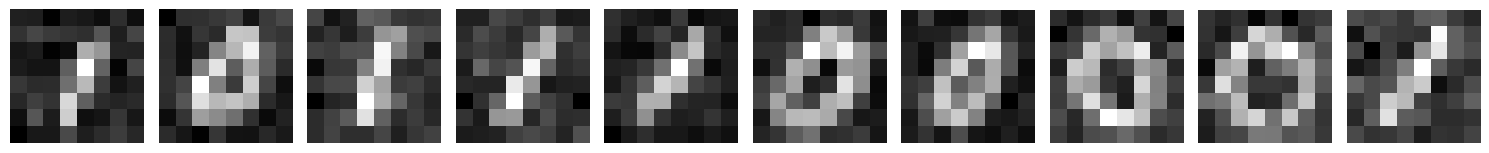

In [11]:
images_true = samples_target.reshape(-1, 8, 8)*std_MNIST + mean_MNIST
# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img = images_true[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    
    axes[i].imshow(np.array(img), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Network size and topology

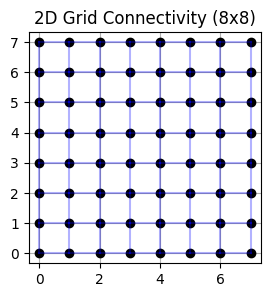

In [12]:
N_osc = 64
connectivity = create_2d_square_grid_connectivity(grid_size=8)
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity, grid_size_x=8, grid_size_y=8)

### Define initial parameters

In [13]:
k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(num_connections)
c_optomech_0 = jnp.zeros(num_connections)
biases_0 = jnp.zeros(N_osc)
params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, biases_0)
params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'biases']
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)


### Bringe energy into correct form

In [14]:
energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)

### Plot initial energy landscape

In [15]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=jnp.random.PRNGKey(1535), num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

#### Optimization parameters and filenames

In [16]:
# # Forward process parameters
# n_time_steps = 5
# t_forward = 1.0
# sigma_forward = .5
# forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-9), jnp.log(t_forward), n_time_steps))
# forward_time_pts = forward_time_pts.at[0].set(0.)
# print('forward_time_pts', forward_time_pts)

# # Optimization parameters
# learning_rate = 100.
# n_epochs = 100000//2
# batch_size = 128
# window_size=1000
# tolerance=1e-8
# patience=50


# comment = "with_external_force_and_duff_constraint_positive_only"
# optimization_folder = (f"{training_method}_"
#            f"t_forward_{t_forward}_"
#            f"n_timesteps_{n_time_steps}_"
#            f"lr_{learning_rate}_"
#            f"epochs_{n_epochs}_"
#            f"batch_{batch_size}_"
#            f"window_{window_size}_"
#            f"tol_{tolerance}_"
#            f"patience_{patience}_"
#            f"{comment}")
# # Setup output directories
# base_dir = "out/problems"
# problem_type_folder = "MNIST"
# problem_folder = f"only_0_and_1_resol_8x8"  # Replace with your actual parameters

# output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# # Create directories if they don't exist
# os.makedirs(output_dir, exist_ok=True)

In [17]:
# # Forward process parameters
# n_time_steps = 50
# t_forward = 1.0
# sigma_forward = .5
# forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-9), jnp.log(t_forward), n_time_steps))
# forward_time_pts = forward_time_pts.at[0].set(0.)
# print('forward_time_pts', forward_time_pts)

# # Optimization parameters
# learning_rate = 100.
# n_epochs = 100000//2
# batch_size = 128
# window_size=1000
# tolerance=1e-8
# patience=50


# comment = "with_external_force_and_duff_constraint_positive_only"
# optimization_folder = (f"{training_method}_"
#            f"t_forward_{t_forward}_"
#            f"n_timesteps_{n_time_steps}_"
#            f"lr_{learning_rate}_"
#            f"epochs_{n_epochs}_"
#            f"batch_{batch_size}_"
#            f"window_{window_size}_"
#            f"tol_{tolerance}_"
#            f"patience_{patience}_"
#            f"{comment}")

# # Setup output directories
# base_dir = "out/problems"
# problem_type_folder = "MNIST"
# problem_folder = f"only_0_and_1_resol_8x8"  # Replace with your actual parameters

# output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# # Create directories if they don't exist
# os.makedirs(output_dir, exist_ok=True)

In [18]:
# # Forward process parameters
# n_time_steps = 50
# t_forward = 1.0
# sigma_forward = .1
# forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-9), jnp.log(t_forward), n_time_steps))
# forward_time_pts = forward_time_pts.at[0].set(0.)
# print('forward_time_pts', forward_time_pts)

# # Optimization parameters
# learning_rate = 100.
# n_epochs = 100000//2
# batch_size = 128
# window_size=1000
# tolerance=1e-8
# patience=50


# comment = f"with_external_force_and_duff_constraint_positive_only_rescaling_{additional_rescaling}"
# optimization_folder = (f"{training_method}_"
#            f"t_forward_{t_forward}_"
#            f"n_timesteps_{n_time_steps}_"
#            f"sigma_forward_{sigma_forward}_"
#            f"lr_{learning_rate}_"
#            f"epochs_{n_epochs}_"
#            f"batch_{batch_size}_"
#            f"window_{window_size}_"
#            f"tol_{tolerance}_"
#            f"patience_{patience}_"
#            f"{comment}")

# # Setup output directories
# base_dir = "out/problems"
# problem_type_folder = "MNIST"
# problem_folder = f"only_0_and_1_resol_8x8"  # Replace with your actual parameters

# output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# # Create directories if they don't exist
# os.makedirs(output_dir, exist_ok=True)

In [22]:
# Forward process parameters
n_time_steps = 50
t_forward = 1.0
sigma_forward = .1
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-9), jnp.log(t_forward), n_time_steps))
forward_time_pts = forward_time_pts.at[0].set(0.)
print('forward_time_pts', forward_time_pts)

# Optimization parameters
learning_rate = 1.
n_epochs = 100000//2
batch_size = 128
window_size=1000
tolerance=1e-8
patience=50


data_folder = ("normalized_data_"
    f"{f'adding_noise_{sigma_images}' if adding_noise else 'NO_added_noise_'}"
    f"{f'rescaling_{additional_rescaling}' if rescaling else 'NO_additional_rescaling_'}"
).strip('_')

comment = f""

optimization_folder = (f"{training_method}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"sigma_forward_{sigma_forward}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}_"
           f"{comment}")

# Setup output directories
base_dir = "out/problems"
problem_type_folder = "MNIST"
problem_folder = f"only_0_and_1_resol_8x8/{data_folder}"  # Replace with your actual parameters

output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

forward_time_pts [0.00000000e+00 1.52641797e-09 2.32995181e-09 3.55648031e-09
 5.42867544e-09 8.28642773e-09 1.26485522e-08 1.93069773e-08
 2.94705170e-08 4.49843267e-08 6.86648845e-08 1.04811313e-07
 1.59985872e-07 2.44205309e-07 3.72759372e-07 5.68986603e-07
 8.68511374e-07 1.32571137e-06 2.02358965e-06 3.08884360e-06
 4.71486636e-06 7.19685673e-06 1.09854114e-05 1.67683294e-05
 2.55954792e-05 3.90693994e-05 5.96362332e-05 9.10298178e-05
 1.38949549e-04 2.12095089e-04 3.23745754e-04 4.94171336e-04
 7.54312006e-04 1.15139540e-03 1.75751062e-03 2.68269580e-03
 4.09491506e-03 6.25055193e-03 9.54095476e-03 1.45634848e-02
 2.22299648e-02 3.39322177e-02 5.17947468e-02 7.90604321e-02
 1.20679264e-01 1.84206997e-01 2.81176870e-01 4.29193426e-01
 6.55128557e-01 1.00000000e+00]
Output directory: out/problems/MNIST/only_0_and_1_resol_8x8/normalized_data_adding_noise_0.07NO_additional_rescaling/SM_t_forward_1.0_n_timesteps_50_sigma_forward_0.1_lr_1.0_epochs_50000_batch_128_window_1000_tol_1e-08_

### Print final distribution of the forward

Saving figure to out/problems/MNIST/only_0_and_1_resol_8x8/normalized_data_adding_noise_0.07NO_additional_rescaling/SM_t_forward_1.0_n_timesteps_50_sigma_forward_0.1_lr_1.0_epochs_50000_batch_128_window_1000_tol_1e-08_patience_50_


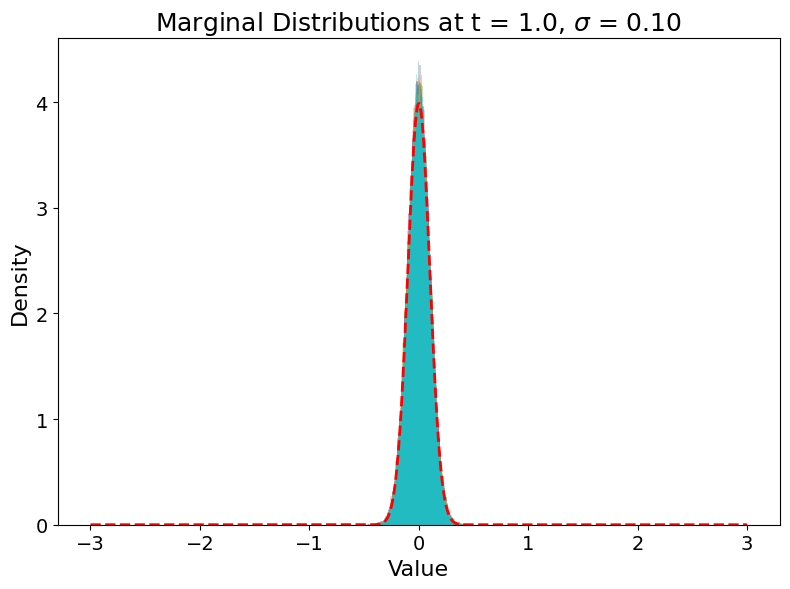

In [23]:
key, subkey = jr.split(key)
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_target, key=subkey)
plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=True, fontsize=16)

In [24]:
load_param_histories = True

if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(f"{output_dir}/params_history.npy")
else:
    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 1     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"Optimization for time {t_curr}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_target, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=True,
                    path=output_dir,
                    param_names=params_names
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)


### Smoothen and interpolate parameter evolution

/home/cbosch/dev/oscillator_dev/mechanical-p-bit/projects/physical-diffusion-models/physical_diffusion_fns/plotting_fns.py:313: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


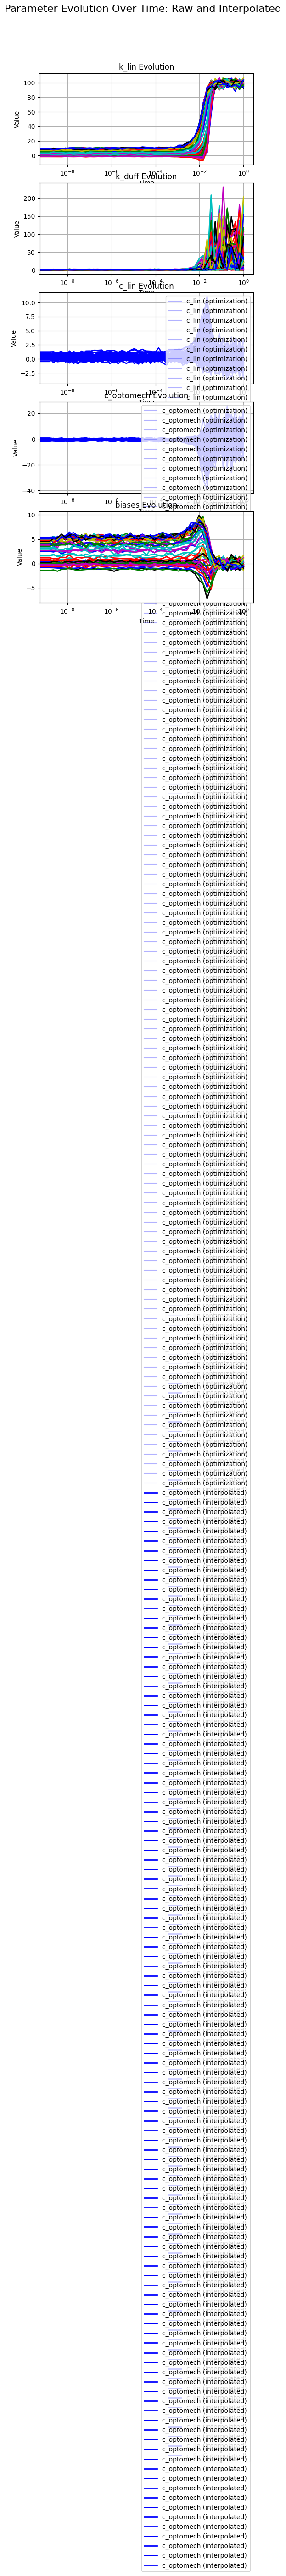

In [25]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths = [10] * params_history_all_t.shape[1], poly_orders = [3] * params_history_all_t.shape[1])
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)


plot_parameter_as_fn_of_time(params_names, forward_time_pts,forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc) 

### Analize params

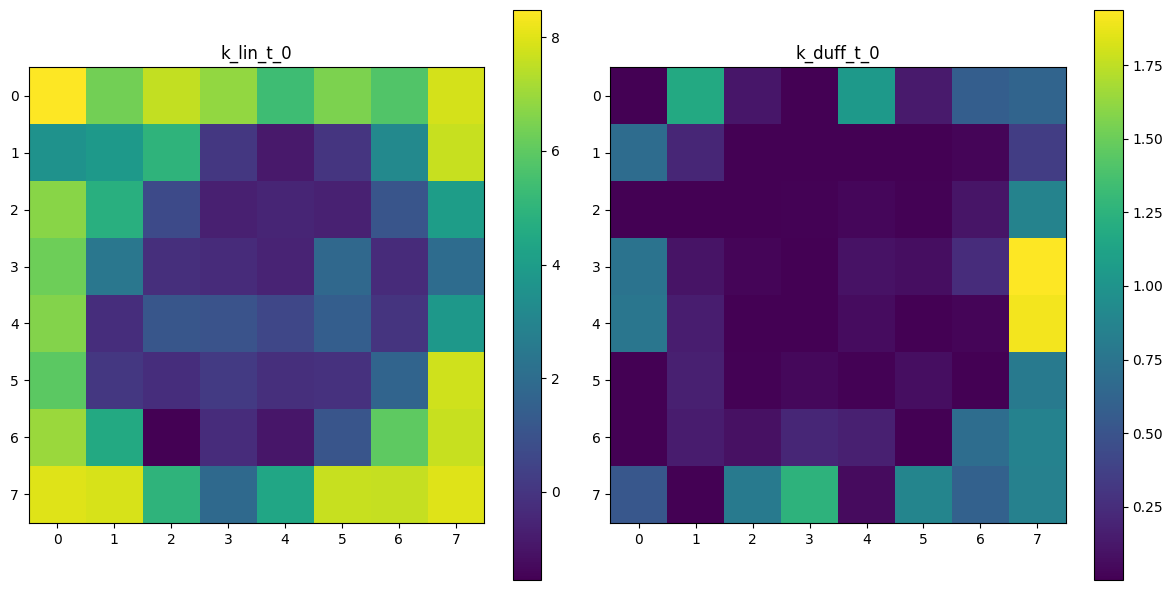

In [26]:
# Assuming params_interpolator is defined and returns the correct values
k_lin_t_0 = params_interpolator(0.0)[0:N_osc]
k_duff_t_0 = params_interpolator(0.0)[N_osc:2*N_osc]

# Reshape to 8x8
k_lin_t_0_reshaped = k_lin_t_0.reshape((8, 8))
k_duff_t_0_reshaped = k_duff_t_0.reshape((8, 8))

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot k_lin_t_0
cax1 = ax[0].imshow(k_lin_t_0_reshaped, cmap='viridis', aspect='equal')
ax[0].set_title('k_lin_t_0')
fig.colorbar(cax1, ax=ax[0])

# Plot k_duff_t_0
cax2 = ax[1].imshow(k_duff_t_0_reshaped, cmap='viridis', aspect='equal')
ax[1].set_title('k_duff_t_0')
fig.colorbar(cax2, ax=ax[1])

plt.tight_layout()
plt.show()

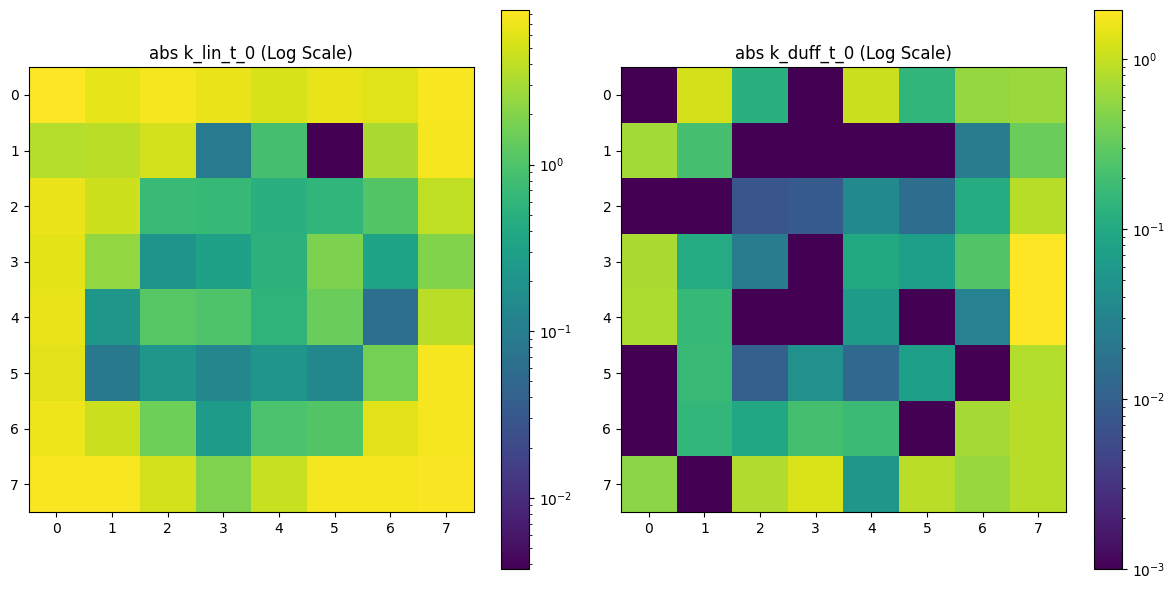

In [27]:
from matplotlib.colors import LogNorm# Assuming params_interpolator is defined and returns the correct values
k_lin_t_0 = params_interpolator(0.0)[0:N_osc]
k_duff_t_0 = params_interpolator(0.0)[N_osc:2*N_osc]

# Reshape to 8x8
k_lin_t_0_reshaped = k_lin_t_0.reshape((8, 8))
k_duff_t_0_reshaped = k_duff_t_0.reshape((8, 8))

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot k_lin_t_0 with logarithmic scale
cax1 = ax[0].imshow(jnp.abs(k_lin_t_0_reshaped), cmap='viridis', norm=LogNorm(), aspect='equal')
ax[0].set_title('abs k_lin_t_0 (Log Scale)')
fig.colorbar(cax1, ax=ax[0])

# Plot k_duff_t_0 with logarithmic scale
cax2 = ax[1].imshow(jnp.abs(k_duff_t_0_reshaped), cmap='viridis', norm=LogNorm(), aspect='equal')
ax[1].set_title('abs k_duff_t_0 (Log Scale)')
fig.colorbar(cax2, ax=ax[1])

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [28]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_forward**2 * forward_params
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

In [29]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001

# Generate multiple initial states
n_trajectories = 10
key, subkey = jr.split(key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=1, samples0=samples_target, key=subkey)

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0,
        rtol=1e-3,
        atol=1e-6
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, N_osc)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, N_osc)
final_states_rescaled = final_states  * std_MNIST + mean_MNIST
images_generated = final_states_rescaled.reshape(-1, 8, 8)

/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

### Plot generated images vs true images

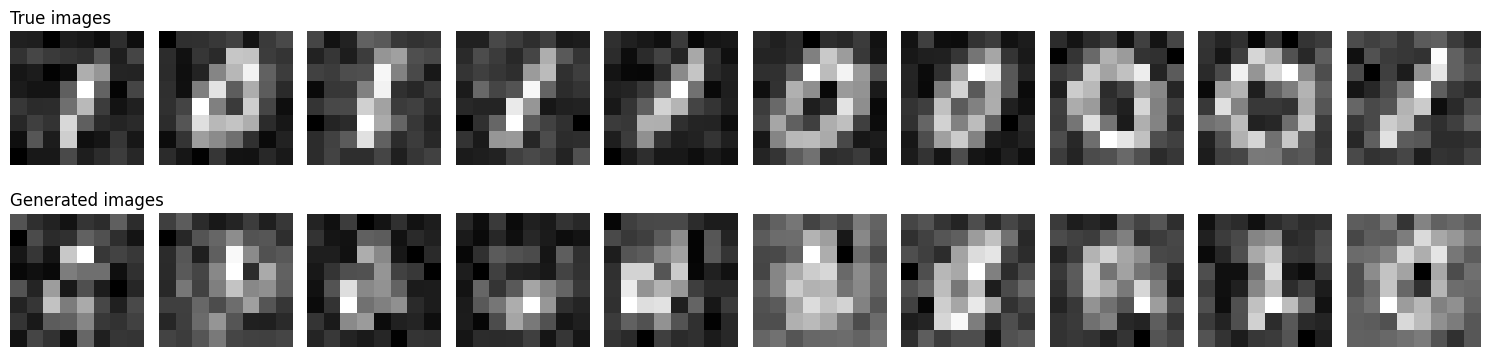

In [30]:
# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(2, num_examples, figsize=(15, 4))  # Create a 2-row grid

# Plot true images
for i in range(num_examples):
    img = images_true[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    axes[0, i].imshow(np.array(img), cmap='gray')
    axes[0, i].axis('off')

# Plot generated images
for i in range(num_examples):
    img_generated = images_generated[i]
    if img_generated.shape[-1] == 1:
        img_generated = img_generated.squeeze(-1)
    axes[1, i].imshow(np.array(img_generated), cmap='gray')
    axes[1, i].axis('off')

# Add titles
axes[0, 0].set_title("True images", loc='left', fontsize=12)
axes[1, 0].set_title("Generated images", loc='left', fontsize=12)

plt.tight_layout()
plt.show()


### Equillibirum Sampling

In [ ]:
# Get parameters from the first time step for equilibrium sampling
params_for_equillibrium_sampling = params_history_all_t[0,:]
# Setup SDE functions
drift_equilibrium_fn, diffusion_equilibrium_fn = setup_overdamped_SDE(energy_fn, params_for_equillibrium_sampling, N_osc, time_dependent_parms=False)

t0 = 0.0
t1 = 100
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001

# Generate multiple initial states
n_trajectories = 1  # or any other number of trajectories you need
n_dimensions = N_osc  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_equilibrium_fn, 
        diffusion_equilibrium_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0,
        rtol=1e-6,
        atol=1e-9
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions_equilibrium = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories_equilibrium = solutions_equilibrium.ys  # Shape: (n_trajectories, n_timesteps, 2)
all_trajectories_equilibrium_rescaled = all_trajectories_equilibrium  * std_MNIST + mean_MNIST
images_equilibrium_generated = all_trajectories_equilibrium_rescaled.reshape(-1, 8, 8)

/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

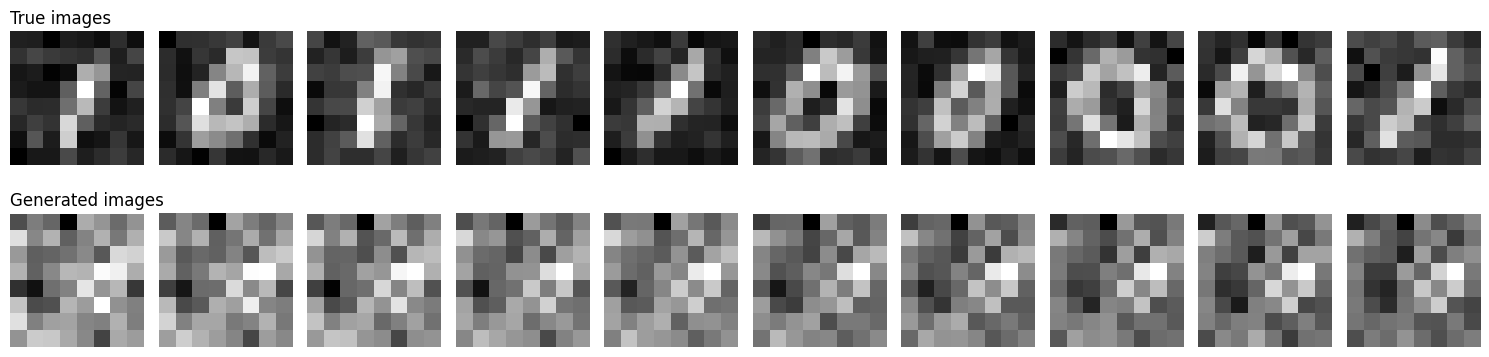

In [33]:
# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(2, num_examples, figsize=(15, 4))  # Create a 2-row grid

# Plot true images
for i in range(num_examples):
    img = images_true[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    axes[0, i].imshow(np.array(img), cmap='gray')
    axes[0, i].axis('off')

# Plot generated images
for i in range(num_examples):
    img_generated = images_equilibrium_generated[i]
    if img_generated.shape[-1] == 1:
        img_generated = img_generated.squeeze(-1)
    axes[1, i].imshow(np.array(img_generated), cmap='gray')
    axes[1, i].axis('off')

# Add titles
axes[0, 0].set_title("True images", loc='left', fontsize=12)
axes[1, 0].set_title("Generated images", loc='left', fontsize=12)

plt.tight_layout()
plt.show()
